<a href="https://colab.research.google.com/github/ricardo-gmarques/estagio/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análise da RAIS 2023 – Setor de TI em São Paulo

Este relatório analisa dados da RAIS 2023 com foco nos profissionais de Tecnologia da Informação no estado de São Paulo.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import mannwhitneyu

In [21]:
from google.colab import files
uploaded = files.upload()

Saving raisfinal-ricardo-gomes_000000000000.csv to raisfinal-ricardo-gomes_000000000000 (1).csv


In [22]:
# Nível de confiança para testes estatísticos
nivel_confianca = 0.01

# Paleta de cores para os gráficos
pal = sns.color_palette("pastel")

color_masc = pal[2]
color_fem = pal[1]

In [23]:
df = pd.read_csv('/content/raisfinal-ricardo-gomes_000000000000.csv')
df.head()

,id_municipio,sexo,idade,grau_instrucao_apos_2005,raca_cor,cbo_2002,cnae_2,valor_remuneracao_media,quantidade_horas_contratadas
0,3550308,1,58,9,6,142525,7020,26000.00,40
1,3550308,1,60,9,2,142525,4645,28981.31,40
2,3512803,1,67,7,2,317120,9001,2036.67,44
3,3550308,1,58,9,8,142525,7420,3366.67,44
4,3547809,1,58,9,2,142525,8532,12852.34,40


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363042 entries, 0 to 363041
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id_municipio                  363042 non-null  int64  
 1   sexo                          363042 non-null  int64  
 2   idade                         363042 non-null  int64  
 3   grau_instrucao_apos_2005      363042 non-null  int64  
 4   raca_cor                      363042 non-null  int64  
 5   cbo_2002                      363042 non-null  int64  
 6   cnae_2                        363042 non-null  int64  
 7   valor_remuneracao_media       363042 non-null  float64
 8   quantidade_horas_contratadas  363042 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 24.9 MB


In [25]:
df.describe()

,id_municipio,sexo,idade,grau_instrucao_apos_2005,raca_cor,cbo_2002,cnae_2,valor_remuneracao_media,quantidade_horas_contratadas
count,3.630420e+05,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000
mean,3.538504e+06,1.217518,35.016574,8.848759,3.733271,223163.358702,6182.625762,9809.056773,46.637138
std,1.787445e+04,0.412558,9.677982,0.585817,2.645201,50453.755655,1474.322617,8720.969277,16.919502
min,3.500105e+06,1.000000,18.000000,2.000000,1.000000,123605.000000,111.000000,1.000000,1.000000
25%,3.524709e+06,1.000000,27.000000,9.000000,2.000000,212405.000000,6201.000000,3863.487500,40.000000
50%,3.550308e+06,1.000000,34.000000,9.000000,2.000000,212405.000000,6204.000000,7452.215000,40.000000
75%,3.550308e+06,1.000000,41.000000,9.000000,6.000000,212420.000000,6611.000000,13122.342500,44.000000
max,3.557303e+06,2.000000,82.000000,11.000000,9.000000,317210.000000,9900.000000,193156.160000,99.000000


In [27]:
df[['Vl Remun Média Nom', 'Salario Hora', 'Idade', 'Qtd Hora Contr']].describe()

,Vl Remun Média Nom,Salario Hora,Idade,Qtd Hora Contr
count,363042.000000,363042.000000,363042.000000,363042.000000
mean,9809.056773,50.945492,35.016574,46.637138
std,8720.969277,74.514517,9.677982,16.919502
min,1.000000,0.230947,18.000000,1.000000
25%,3863.487500,20.291506,27.000000,40.000000
50%,7452.215000,37.793731,34.000000,40.000000
75%,13122.342500,66.974596,41.000000,44.000000
max,193156.160000,22753.078522,82.000000,99.000000


In [43]:
for col in df.columns:
    print(f"'{col}'")

'Município'
'Sexo Trabalhador'
'Idade'
'Escolaridade após 2005'
'Raça Cor'
'CBO Ocupação 2002'
'cnae_2'
'Vl Remun Média Nom'
'Qtd Hora Contr'
'Horas Mensais'
'Salario Hora'


In [44]:
df.columns = df.columns.str.strip().str.lower()

In [46]:
df.columns

Index(['município', 'sexo trabalhador', 'idade', 'escolaridade após 2005',
       'raça cor', 'cbo ocupação 2002', 'cnae_2', 'vl remun média nom',
       'qtd hora contr', 'horas mensais', 'salario hora'],
      dtype='object')

In [47]:
print("###################################\n")
print("Limpeza e preparação dos dados RAIS 2023\n")

# Padronizar nomes das colunas
df.columns = df.columns.str.strip().str.lower()

print("Linhas iniciais:", len(df))

# Garantir campos numéricos
df['vl remun média nom'] = pd.to_numeric(df['vl remun média nom'], errors='coerce')
df['qtd hora contr'] = pd.to_numeric(df['qtd hora contr'], errors='coerce')
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')

# Remover registros inválidos
df = df[df['vl remun média nom'] > 0]
df = df[df['qtd hora contr'] > 0]
df = df[df['idade'].between(18, 90)]

# Remover escolaridade analfabeto, se existir
df = df[df['escolaridade após 2005'] != 'Analfabeto']

# Recriar salário por hora
df['horas mensais'] = df['qtd hora contr'] * 4.33
df['salario hora'] = df['vl remun média nom'] / df['horas mensais']

print("Linhas após limpeza:", len(df))
display(df.head())

print("\n###################################")

###################################

Limpeza e preparação dos dados RAIS 2023

Linhas iniciais: 363042
Linhas após limpeza: 363042


,município,sexo trabalhador,idade,escolaridade após 2005,raça cor,cbo ocupação 2002,cnae_2,vl remun média nom,qtd hora contr,horas mensais,salario hora
0,3550308,Masculino,58,Superior completo,6,142525,7020,26000.00,40,173.20,150.115473
1,3550308,Masculino,60,Superior completo,2,142525,4645,28981.31,40,173.20,167.328580
2,3512803,Masculino,67,Médio completo,2,317120,9001,2036.67,44,190.52,10.690059
3,3550308,Masculino,58,Superior completo,8,142525,7420,3366.67,44,190.52,17.670953
4,3547809,Masculino,58,Superior completo,2,142525,8532,12852.34,40,173.20,74.205196



###################################


In [48]:
# 5. Separação por sexo

df_masculino = df[df['sexo trabalhador'] == 'Masculino']
df_feminino = df[df['sexo trabalhador'] == 'Feminino']

print("Homens:", len(df_masculino))
print("Mulheres:", len(df_feminino))

Homens: 284074
Mulheres: 78968


In [50]:
# 6. Cálculo de média, mediana e massa salarial por sexo

media_masculino = df_masculino['vl remun média nom'].mean()
media_feminino = df_feminino['vl remun média nom'].mean()

mediana_masculino = df_masculino['vl remun média nom'].median()
mediana_feminino = df_feminino['vl remun média nom'].median()

massa_masculino = df_masculino['vl remun média nom'].sum()
massa_feminino = df_feminino['vl remun média nom'].sum()

# Impressão formatada
print(f"Média masculina: R$ {media_masculino:.2f}")
print(f"Média feminina: R$ {media_feminino:.2f}")

print(f"Mediana masculina: R$ {mediana_masculino:.2f}")
print(f"Mediana feminina: R$ {mediana_feminino:.2f}")

print(f"Massa salarial masculina: R$ {massa_masculino:.2f}")
print(f"Massa salarial feminina: R$ {massa_feminino:.2f}")

Média masculina: R$ 10083.81
Média feminina: R$ 8820.66
Mediana masculina: R$ 7733.28
Mediana feminina: R$ 6543.96
Massa salarial masculina: R$ 2864549580.68
Massa salarial feminina: R$ 696550008.20


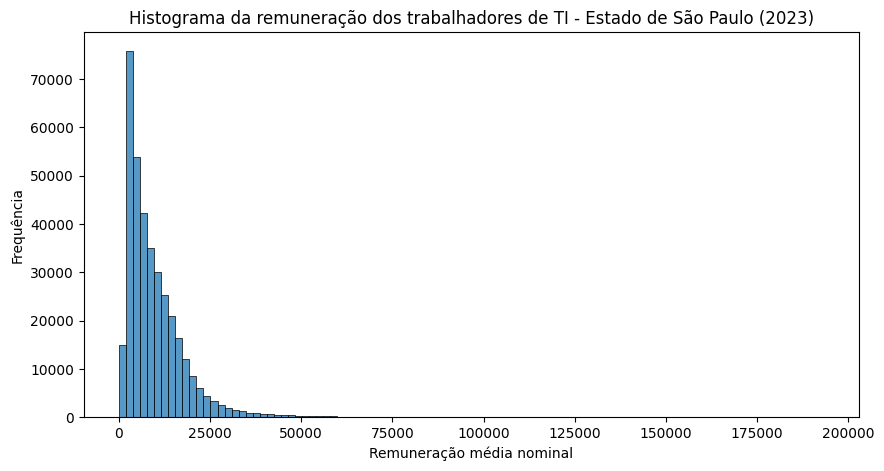

In [51]:
# 7. Histograma da remuneração - Estado de São Paulo

plt.figure(figsize=(10, 5))

sns.histplot(df['vl remun média nom'], bins=100)

plt.title('Histograma da remuneração dos trabalhadores de TI - Estado de São Paulo (2023)')
plt.xlabel('Remuneração média nominal')
plt.ylabel('Frequência')

plt.show()

In [53]:
# 8. Análise dos maiores e menores salários

# Ordenar salários
df_ordenado = df.sort_values(by='vl remun média nom', ascending=False)

# 1% mais ricos
qtd_1_porcento = int(len(df_ordenado) * 0.01)
top_1 = df_ordenado.head(qtd_1_porcento)

soma_top_1 = top_1['vl remun média nom'].sum()
qtd_top_1 = len(top_1)

print(f"Soma dos salários dos trabalhadores 1% mais ricos: R$ {soma_top_1:.2f}")
print(f"Quantidade de trabalhadores 1% mais ricos: {qtd_top_1}")

Soma dos salários dos trabalhadores 1% mais ricos: R$ 212428282.02
Quantidade de trabalhadores 1% mais ricos: 3630


In [54]:
# 9. Comparação com os mais pobres

# Ordenar do menor para o maior
df_pobres = df.sort_values(by='vl remun média nom', ascending=True)

soma_acumulada = 0
qtd_pobres = 0

for salario in df_pobres['vl remun média nom']:
    soma_acumulada += salario
    qtd_pobres += 1

    if soma_acumulada >= soma_top_1:
        break

print(f"Soma dos salários dos trabalhadores mais pobres: R$ {soma_acumulada:.2f}")
print(f"Quantidade de trabalhadores mais pobres: {qtd_pobres}")
print(f"Percentual da base: {(qtd_pobres / len(df)) * 100:.2f}%")

Soma dos salários dos trabalhadores mais pobres: R$ 212429192.79
Quantidade de trabalhadores mais pobres: 83870
Percentual da base: 23.10%


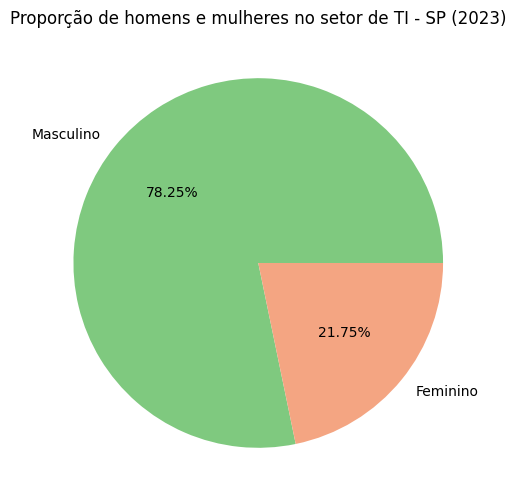

In [55]:
# 10. Proporção de homens e mulheres (gráfico pizza)

# Contagem
qtd_masculino = len(df_masculino)
qtd_feminino = len(df_feminino)

# Dados
valores = [qtd_masculino, qtd_feminino]
labels = ['Masculino', 'Feminino']

# Gráfico
plt.figure(figsize=(6,6))

plt.pie(valores, labels=labels, autopct='%1.2f%%', colors=['#7fc97f', '#f4a582'])

plt.title('Proporção de homens e mulheres no setor de TI - SP (2023)')

plt.show()

In [56]:
# Impressão dos valores

print(f"Quantidade trabalhadores masculinos: {qtd_masculino}")
print(f"Quantidade trabalhadores femininos: {qtd_feminino}")

razao = qtd_masculino / qtd_feminino

print(f"São aproximadamente {razao:.2f} vezes mais homens que mulheres.")

Quantidade trabalhadores masculinos: 284074
Quantidade trabalhadores femininos: 78968
São aproximadamente 3.60 vezes mais homens que mulheres.


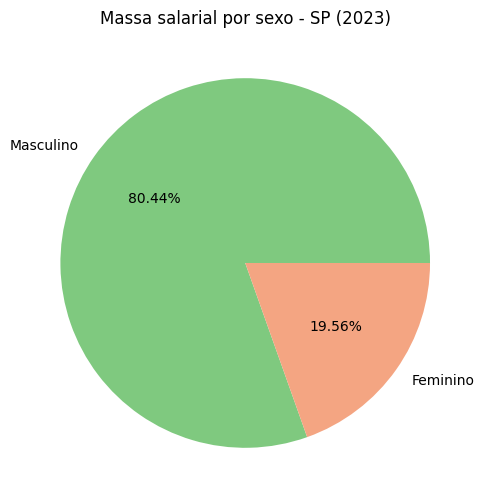

Massa salarial trabalhadores masculinos: R$ 2.864.549.580,68
Massa salarial trabalhadores femininos: R$ 696.550.008,20
A massa salarial dos homens é 4.11 vezes maior que a das mulheres.


In [57]:
# 11. Massa salarial por sexo (gráfico pizza)

# Soma das remunerações
massa_masculino = df_masculino['vl remun média nom'].sum()
massa_feminino = df_feminino['vl remun média nom'].sum()

# Dados
valores = [massa_masculino, massa_feminino]
labels = ['Masculino', 'Feminino']

# Gráfico
plt.figure(figsize=(6,6))

plt.pie(valores, labels=labels, autopct='%1.2f%%', colors=['#7fc97f', '#f4a582'])

plt.title('Massa salarial por sexo - SP (2023)')

plt.show()

# Impressão dos valores

def br(valor):
    return f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print(f"Massa salarial trabalhadores masculinos: R$ {br(massa_masculino)}")
print(f"Massa salarial trabalhadores femininos: R$ {br(massa_feminino)}")

razao_massa = massa_masculino / massa_feminino

print(f"A massa salarial dos homens é {razao_massa:.2f} vezes maior que a das mulheres.")

/tmp/ipykernel_14534/2923743726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


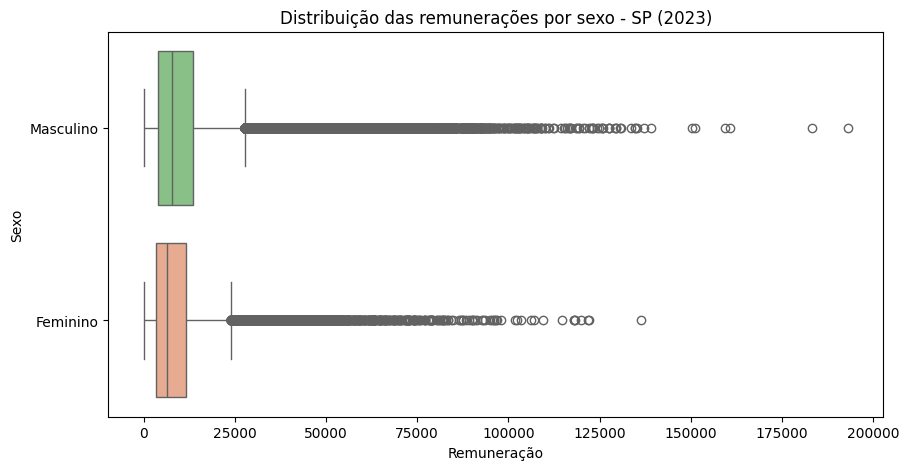

In [58]:
# 12. Distribuição salarial por sexo (boxplot)

plt.figure(figsize=(10,5))

sns.boxplot(
    x='vl remun média nom',
    y='sexo trabalhador',
    data=df,
    palette=['#7fc97f', '#f4a582']
)

plt.title('Distribuição das remunerações por sexo - SP (2023)')
plt.xlabel('Remuneração')
plt.ylabel('Sexo')

plt.show()

In [59]:
# 13. Estatísticas salariais

media_m = df_masculino['vl remun média nom'].mean()
media_f = df_feminino['vl remun média nom'].mean()

mediana_m = df_masculino['vl remun média nom'].median()
mediana_f = df_feminino['vl remun média nom'].median()

# Diferenças
dif_media = media_m - media_f
dif_mediana = mediana_m - mediana_f

perc_media = (dif_media / media_m) * 100
perc_mediana = (dif_mediana / mediana_m) * 100

In [60]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    df_masculino['vl remun média nom'],
    df_feminino['vl remun média nom']
)

In [61]:
def br(valor):
    return f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print("Masculino:")
print(f"Média: R$ {br(media_m)}")
print(f"Mediana: R$ {br(mediana_m)}\n")

print("Feminino:")
print(f"Média: R$ {br(media_f)}")
print(f"Mediana: R$ {br(mediana_f)}\n")

print(f"Diferença média: R$ {br(dif_media)}")
print(f"Variação percentual média: {-perc_media:.2f}%\n")

print(f"Diferença mediana: R$ {br(dif_mediana)}")
print(f"Variação percentual mediana: {-perc_mediana:.2f}%\n")

print(f"Estatística Mann-Whitney: {stat:.2f}")
print(f"p-valor: {p:.15f}")

if p < 0.05:
    print("Resultado: rejeitar H0 (há diferença salarial)")
else:
    print("Resultado: não rejeitar H0")

Masculino:
Média: R$ 10.083,81
Mediana: R$ 7.733,28

Feminino:
Média: R$ 8.820,66
Mediana: R$ 6.543,96

Diferença média: R$ 1.263,15
Variação percentual média: -12.53%

Diferença mediana: R$ 1.189,32
Variação percentual mediana: -15.38%

Estatística Mann-Whitney: 12252848874.50
p-valor: 0.000000000000000
Resultado: rejeitar H0 (há diferença salarial)


In [29]:
df['Sexo Trabalhador'].value_counts()

,count
Sexo Trabalhador,
Masculino,284074
Feminino,78968


In [30]:
df.groupby('Sexo Trabalhador')['Vl Remun Média Nom'].mean()


,Vl Remun Média Nom
Sexo Trabalhador,
Feminino,8820.661638
Masculino,10083.814713


In [31]:
df.groupby('Sexo Trabalhador')['Vl Remun Média Nom'].median()

,Vl Remun Média Nom
Sexo Trabalhador,
Feminino,6543.96
Masculino,7733.28


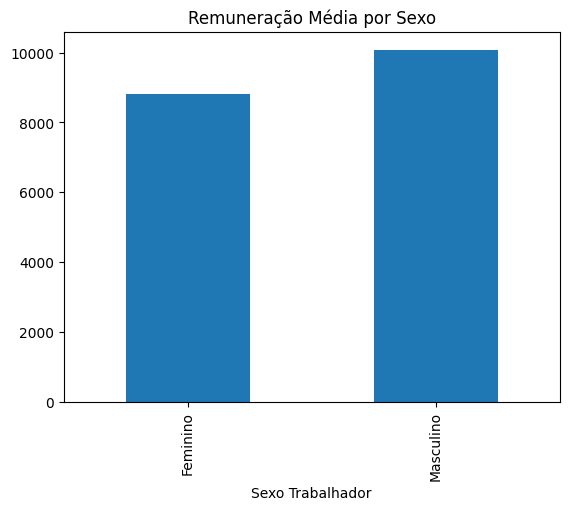

In [32]:
df.groupby('Sexo Trabalhador')['Vl Remun Média Nom'].mean().plot(kind='bar')
plt.title('Remuneração Média por Sexo')
plt.show()

In [33]:
ordem = [

    'Até 5ª incompleta',
    '5ª completa Fundamental',
    '6ª a 9ª Fundamental',
    'Fundamental completo',
    'Médio incompleto',
    'Médio completo',
    'Superior incompleto',
    'Superior completo',
    'Mestrado',
    'Doutorado'
]

df['Escolaridade após 2005'] = pd.Categorical(
    df['Escolaridade após 2005'],
    categories=ordem,
    ordered=True
)

In [34]:
df['Escolaridade após 2005'].value_counts().sort_index()

,count
Escolaridade após 2005,
Até 5ª incompleta,22
5ª completa Fundamental,21
6ª a 9ª Fundamental,69
Fundamental completo,421
Médio incompleto,809
Médio completo,22644
Superior incompleto,13472
Superior completo,318335
Mestrado,5909


In [35]:
df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean().sort_index()

/tmp/ipykernel_14534/367872448.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean().sort_index()


,Vl Remun Média Nom
Escolaridade após 2005,
Até 5ª incompleta,4778.459545
5ª completa Fundamental,4104.114762
6ª a 9ª Fundamental,3950.839710
Fundamental completo,3693.776461
Médio incompleto,3233.529011
Médio completo,3607.734538
Superior incompleto,4612.790254
Superior completo,10290.785792
Mestrado,18921.254260


In [36]:
df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].median().sort_index()

/tmp/ipykernel_14534/1374599943.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].median().sort_index()


,Vl Remun Média Nom
Escolaridade após 2005,
Até 5ª incompleta,3564.580
5ª completa Fundamental,3518.190
6ª a 9ª Fundamental,3001.860
Fundamental completo,2879.590
Médio incompleto,2363.030
Médio completo,2607.570
Superior incompleto,3274.070
Superior completo,8120.970
Mestrado,15342.170


/tmp/ipykernel_14534/2775709446.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean().plot(kind='bar')


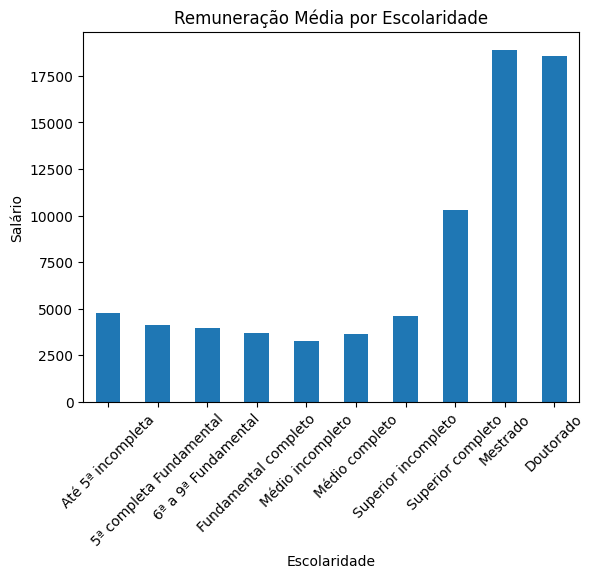

In [37]:
import matplotlib.pyplot as plt

df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean().plot(kind='bar')

plt.title('Remuneração Média por Escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Salário')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.groupby('Escolaridade após 2005')['Salario Hora'].mean().sort_index()

In [38]:
media = df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean()

variacao = media.pct_change() * 100

resultado = pd.DataFrame({
    'Salário Médio': media,
    'Variação (%)': variacao
})

resultado.round(2)

/tmp/ipykernel_14534/2410468628.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media = df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean()


,Salário Médio,Variação (%)
Escolaridade após 2005,,
Até 5ª incompleta,4778.46,NaN
5ª completa Fundamental,4104.11,-14.11
6ª a 9ª Fundamental,3950.84,-3.73
Fundamental completo,3693.78,-6.51
Médio incompleto,3233.53,-12.46
Médio completo,3607.73,11.57
Superior incompleto,4612.79,27.86
Superior completo,10290.79,123.09
Mestrado,18921.25,83.87
